In [3]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.self_consistency import bdg_sc

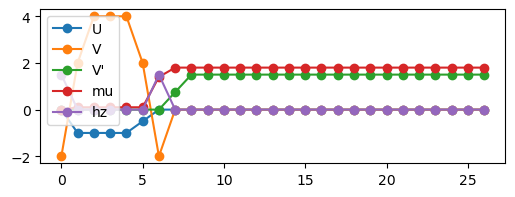

In [13]:
widthD = 5
widthF = 1
widthN = 1
widthP = 20

X, Y = widthN+widthD+widthF+widthP, 100
lattice = Lattice(X, Y)

t = 1
T = 0.01

muD = 0.1 * t
muP = 1.8 * t
muF = 1.4 * t
muN = 1.4 * t
mu = np.zeros(lattice.X)
mu[widthN:] = muN
mu[widthN:widthD + widthN] = muD
mu[widthD + widthN:widthD + widthF + widthN] = muF
mu[widthD + widthF + widthN:] = muP

h0 = 1.5 * t
h = np.zeros_like(mu)
h[:widthN:] = h0
h[widthD + widthN:widthD + widthF + widthN] = h0

U0 = -1.0 * t
U = U0 * np.ones(lattice.X)
U[widthD + widthN:] = 0
U[:widthN:] = 0

U[widthD + widthN - 1] = U0/2

V0 = 4.0 * t
V = V0 * np.ones(lattice.X)
V[:widthN:] = -2
V[widthD + widthN:] = 0
V[widthD + widthN - 1] = V0/2
V[widthN] = V0/2
V[widthD + widthN] = -2

V_prime0 = 1.5 * t
V_prime = V_prime0 * np.ones(lattice.X)
V_prime[:widthF+widthD + widthN] = 0
V_prime[widthF+widthD + widthN] = V_prime0/2

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(h, '-o', label='hz')

plt.legend()

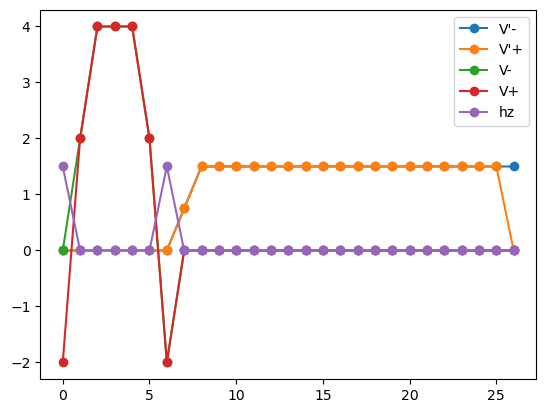

In [14]:
V_plus = np.r_[V[:-1], [0]]
V_minus = np.r_[[0], V[1:]]
Vprime_plus = np.r_[V_prime[:-1], [0]]
Vprime_minus = np.r_[[0], V_prime[1:]]

plt.plot(Vprime_minus, "-o", label="V'-")
plt.plot(Vprime_plus, "-o", label="V'+")
plt.plot(V_minus, "-o", label="V-")
plt.plot(V_plus, "-o", label="V+")
plt.plot(h, '-o', label='hz')
plt.legend()

In [15]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.5, 0.5, -0.5, -0.5],
                Fuu_init=[0.1, -0.1, 0.1j, -0.1j],
                Fdd_init=[0.1, -0.1, 0.1j, -0.1j],
                hx=h)

In [16]:
bdg_sc(H, atol=1e-3, rtol=0.1, maxiter=100, temperature=T,verbose=True)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 0.014435151826719167
Relative error: 14435151826.71917
Average old: 0j
Average: (0.0011474202824712538+0j)
F_xplus:
Absolute error: 0.8068097514311907
Relative error: 32320160734.73689
Average old: (0.09615384615384616+0j)
Average: (0.04958994063146023+0j)
F_xmin:
Absolute error: 0.7960138644648803
Relative error: 28922025281.034008
Average old: (0.09615384615384616+0j)
Average: (0.04746552565735878+0j)
F_yplus:
Absolute error: 0.3323485963515172
Relative error: 36173332445.96315
Average old: (-0.09259259259259259+0j)
Average: (-0.06534794049678133+6.43807739951667e-05j)
F_ymin:
Absolute error: 0.3323485963515172
Relative error: 36173332445.96315
Average old: (-0.09259259259259259+0j)
Average: (-0.06534794049678133-6.43807739951667e-05j)
Fuu_xplus:
Absolute error: 0.1017946254718396
Relative error: 46884860603.51403
Average old: (0.0730769230769231+0j)
Average: (0.08629763867550277+0j)
Fuu_xmin:
Absolute error: 0.11805162880689253
Relative error: 34279363213.86016
A

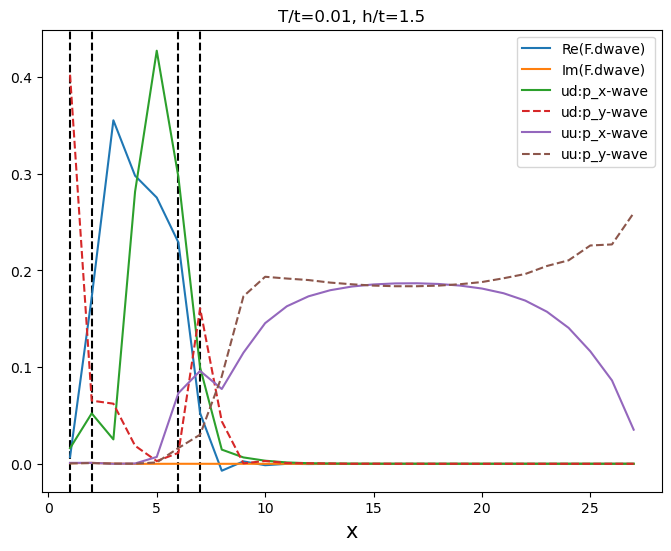

In [17]:
x = np.arange(1, widthN + widthD + widthF + widthP + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}, h/t={h0}")
axs.axvline(widthN+1, color='black', linestyle='--')
axs.axvline(widthN, color='black', linestyle='--')
axs.axvline(widthD+widthN, color='black', linestyle='--')
axs.axvline(widthD+widthF+widthN, color='black', linestyle='--')
axs.plot(x, np.real(F.dwave), label="Re(F.dwave)")
axs.plot(x, np.imag(F.dwave), label="Im(F.dwave)")
axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.plot(x, np.abs(Fuu.px), label="uu:p_x-wave")
axs.plot(x, np.abs(Fuu.py), "--", label="uu:p_y-wave")
axs.set_xlabel("x", fontsize=15)
axs.legend()
plt.show()

In [18]:
temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.25 + 1e-12, 0.01),
    np.arange(0.26, 0.6 + 1e-12, 0.002 )
])  # 164 temps total
print(len(temps))

205
